In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [39]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [40]:
cov = pd.read_csv("data/Degron_PolII_merged_cov_boxplot.csv")
pause = pd.read_csv("data/Degron_PolII_pausing_ratio_with_metatadata.csv")

In [41]:
condition_map = {"D8L4Y_0h": "0 h", "D8L4Y_90min": "1.5 h", "D8L4Y_8h": "8 h"}
cov = cov[
    [
        "chr",
        "start",
        "end",
        "bin",
        "gene_id",
        "hgnc_symbol",
        "coverage",
        "dataset",
        "condition",
        "target",
        "coverage.fold",
    ]
]
cov = cov.assign(condition=lambda x: x.condition.map(condition_map))
cov["region"] = pd.Categorical(cov["dataset"], ["TSS", "Gene Body", "TTS"])
cov["condition"] = pd.Categorical(cov["condition"], ["0 h", "1.5 h", "8 h"])
pause["condition"] = pause["condition"].map(condition_map)
pause["condition"] = pd.Categorical(pause["condition"], ["0 h", "1.5 h", "8 h"])

In [42]:
# keep only genes with TSS coverage > 0.5 at 0h
expressed_genes = cov[(cov["region"] == "TSS") & (cov["condition"] == "0 h")].loc[
    lambda df: df["coverage"] > 0.5, "gene_id"
]

cov = cov[cov["gene_id"].isin(expressed_genes)]

print(
    f"Genes passing filter: {cov['gene_id'].nunique():,}  (removed {9860 - cov['gene_id'].nunique():,})"
)

Genes passing filter: 8,382  (removed 1,478)


In [43]:
cov["length"] = (cov["start"] - cov["end"]).abs()
pause["length"] = pause["length"]

print("Min cov length:", cov["length"].min())
print("Min pause length:", pause["length"].min())

Min cov length: 1000
Min pause length: 1004


/var/folders/bk/jfxwkhls69b5qm00y25gv6200000gp/T/ipykernel_62011/608446583.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region")["coverage.fold"]


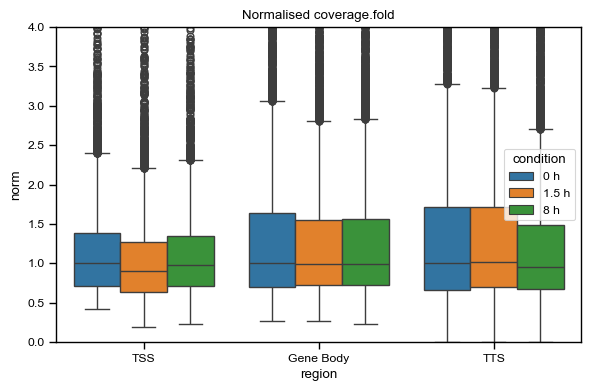

In [44]:
med = (
    cov[cov["condition"] == "0 h"]
    .groupby("region")["coverage.fold"]
    .median()
    .rename("median")
    .reset_index()
)

norm = cov.merge(med, on="region")
norm["norm"] = norm["coverage.fold"] / norm["median"]

plt.figure(figsize=(6, 4))
sns.boxplot(data=norm, x="region", y="norm", hue="condition")
plt.ylim(0, 4)
plt.title("Normalised coverage.fold")
plt.tight_layout()
plt.show()

In [45]:
zero = cov[cov["condition"] == "0 h"][["gene_id", "region", "coverage.fold"]]
short = cov[cov["condition"] == "1.5 h"][["gene_id", "region", "coverage.fold"]]
long = cov[cov["condition"] == "8 h"][["gene_id", "region", "coverage.fold"]]

print(len(zero) == len(short))
print(len(zero) == len(long))

True
True


In [46]:
short_fc = short.merge(zero, on=["gene_id", "region"], suffixes=("_1.5h", "_0h"))
short_fc["log2FC"] = np.log2(
    short_fc["coverage.fold_1.5h"] / short_fc["coverage.fold_0h"]
)
short_fc["condition"] = "1.5 h"

long_fc = long.merge(zero, on=["gene_id", "region"], suffixes=("_8h", "_0h"))
long_fc["log2FC"] = np.log2(long_fc["coverage.fold_8h"] / long_fc["coverage.fold_0h"])
long_fc["condition"] = "8 h"

all_fc = pd.concat([short_fc, long_fc])

In [47]:
threshold = 0.5  # log2FC threshold

for condition in ["1.5 h", "8 h"]:
    for region in ["TSS", "Gene Body"]:
        subset = all_fc[
            (all_fc["condition"] == condition) & (all_fc["region"] == region)
        ]
        n_total = len(subset)
        n_stable = (subset["log2FC"].abs() < threshold).sum()
        fraction = n_stable / n_total
        print(
            f"{condition}, {region}: "
            f"{n_stable}/{n_total} genes have |log2FC| < {threshold}  →  {fraction:.1%}"
        )

1.5 h, TSS: 7989/8382 genes have |log2FC| < 0.5  →  95.3%
1.5 h, Gene Body: 7625/7677 genes have |log2FC| < 0.5  →  99.3%
8 h, TSS: 8071/8382 genes have |log2FC| < 0.5  →  96.3%
8 h, Gene Body: 7611/7677 genes have |log2FC| < 0.5  →  99.1%


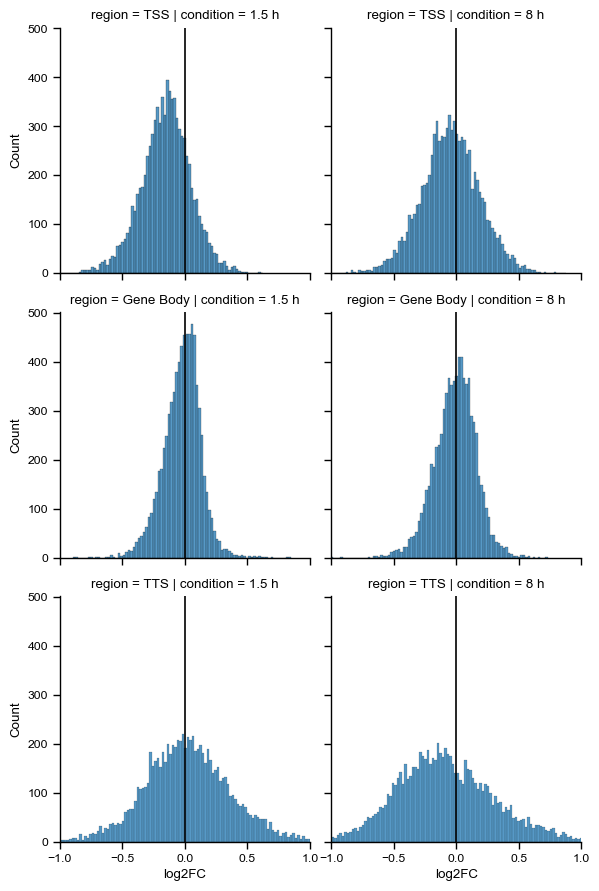

In [48]:
g = sns.FacetGrid(all_fc, col="condition", row="region", sharex=True, sharey=True)
g.map(sns.histplot, "log2FC", binwidth=0.02)
for ax in g.axes.flat:
    ax.axvline(0, color="black")
plt.xlim(-1, 1)
plt.show()

In [49]:
short_plot = short_fc[short_fc["region"] != "TTS"]
long_plot = long_fc[long_fc["region"] != "TTS"]

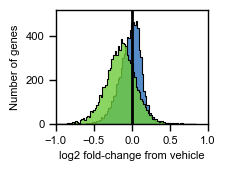

In [50]:
sns.set_context("paper")

f, a = plt.subplots(figsize=(3, 1.8))

pal = sns.color_palette(["xkcd:apple", "xkcd:medium blue", "grey"])

sns.histplot(
    data=short_plot,
    x="log2FC",
    hue="region",
    edgecolor="black",
    palette=pal,
    binwidth=0.02,
    alpha=0.8,
    element="step",
    legend=False,
)

a.set_box_aspect(0.75)
plt.xlim(-1, 1)
plt.ylim(0, 520)
plt.axvline(0, color="black", linewidth=2)
plt.ylabel("Number of genes", fontsize=8)
plt.xlabel("log2 fold-change from vehicle", fontsize=8)
plt.tick_params(axis="both", labelsize=8)
plt.tight_layout()

plt.savefig("0_vs_90min_TSSgreen_GBblue.svg")

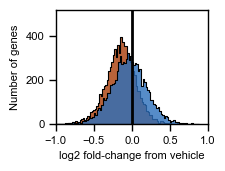

In [51]:
sns.set_context("paper")

f, a = plt.subplots(figsize=(3, 1.8))

pal = sns.color_palette(["xkcd:apple", "xkcd:medium blue", "grey"])

sns.histplot(
    data=short_plot.query('region == "TSS"'),
    x="log2FC",
    color="xkcd:rust",
    edgecolor="black",
    binwidth=0.02,
    element="step",
    alpha=0.8,
    legend=False,
)

sns.histplot(
    data=long_plot.query('region == "TSS"'),
    x="log2FC",
    color="xkcd:medium blue",
    edgecolor="black",
    binwidth=0.02,
    element="step",
    alpha=0.8,
    legend=False,
)


a.set_box_aspect(0.75)
plt.xlim(-1, 1)
plt.ylim(0, 520)
plt.axvline(0, color="black", linewidth=2)
plt.ylabel("Number of genes", fontsize=8)
plt.xlabel("log2 fold-change from vehicle", fontsize=8)
plt.tick_params(axis="both", labelsize=8)
plt.tight_layout()

plt.savefig("0_vs_90min_rust_8hour_blue_TSS.svg")

In [52]:
# Compute fold change of summed coverage - weights by expression level
for region in ["TSS", "Gene Body"]:
    subset = short_fc[short_fc["region"] == region]

    # Sum total coverage at each timepoint
    total_cov_0h = subset["coverage.fold_0h"].sum()
    total_cov_1_5h = subset["coverage.fold_1.5h"].sum()

    summed_fc = total_cov_1_5h / total_cov_0h

    print(f"\n{region}:")
    print(f"  Total coverage at 0h: {total_cov_0h:.1f}")
    print(f"  Total coverage at 1.5h: {total_cov_1_5h:.1f}")
    print(f"  Fold change (summed): {summed_fc:.4f}")


TSS:
  Total coverage at 0h: 51344.9
  Total coverage at 1.5h: 46599.7
  Fold change (summed): 0.9076

Gene Body:
  Total coverage at 0h: 12316.7
  Total coverage at 1.5h: 11808.8
  Fold change (summed): 0.9588


Genes per condition (after dropna): {'0 h': 7677, '1.5 h': 7677, '8 h': 7677}


/var/folders/bk/jfxwkhls69b5qm00y25gv6200000gp/T/ipykernel_62011/2647149880.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cov[cov["region"].isin(["TSS", "Gene Body"])]
/var/folders/bk/jfxwkhls69b5qm00y25gv6200000gp/T/ipykernel_62011/2647149880.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f"Genes per condition (after dropna): {pivot.groupby('condition').size().to_dict()}"
/opt/homebrew/anaconda3/envs/spots-py310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


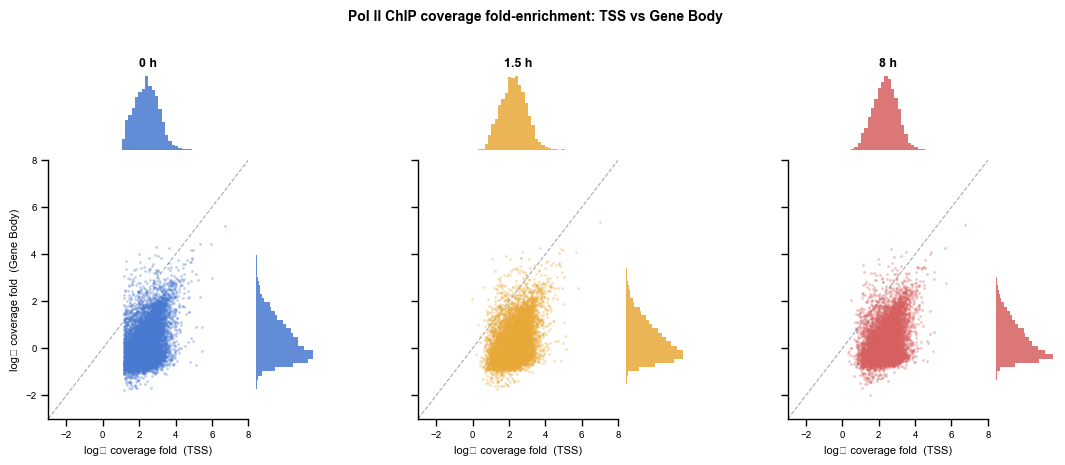

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

pivot = (
    cov[cov["region"].isin(["TSS", "Gene Body"])]
    .pivot_table(
        index=["gene_id", "condition"],
        columns="region",
        values="coverage.fold",
    )
    .reset_index()
    .dropna()
)
pivot.columns.name = None
pivot = pivot.rename(columns={"TSS": "TSS_cov", "Gene Body": "GB_cov"})

# log2-transform (clip near-zero values to avoid -inf)
pivot["log2_TSS"] = np.log2(pivot["TSS_cov"].clip(lower=1e-3))
pivot["log2_GB"] = np.log2(pivot["GB_cov"].clip(lower=1e-3))

print(
    f"Genes per condition (after dropna): {pivot.groupby('condition').size().to_dict()}"
)

conditions = ["0 h", "1.5 h", "8 h"]
palette = {"0 h": "#4878CF", "1.5 h": "#E8A838", "8 h": "#D65F5F"}
lims = (-3, 8)  # log2 axis range — adjust if your data extends further

fig = plt.figure(figsize=(13, 4.5))
fig.patch.set_facecolor("white")

outer_gs = GridSpec(1, 3, figure=fig, wspace=0.38)

for col_idx, cond in enumerate(conditions):
    df = pivot[pivot["condition"] == cond]
    color = palette[cond]

    # 2×2 sub-grid: top-left = top marginal, bottom-left = scatter,
    #               bottom-right = right marginal (corner cell unused)
    inner_gs = outer_gs[col_idx].subgridspec(
        2,
        2,
        width_ratios=[4, 1.2],
        height_ratios=[1.2, 4],
        hspace=0.06,
        wspace=0.06,
    )

    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_top_hist = fig.add_subplot(inner_gs[0, 0], sharex=ax_scatter)
    ax_rgt_hist = fig.add_subplot(inner_gs[1, 1], sharey=ax_scatter)

    # ── scatter ──────────────────────────────────────────────────────────────
    ax_scatter.scatter(
        df["log2_TSS"],
        df["log2_GB"],
        s=4,
        alpha=0.35,
        color=color,
        linewidths=0,
        rasterized=True,
    )

    # diagonal reference line (TSS = GB)
    ax_scatter.plot(lims, lims, lw=0.8, ls="--", color="#aaaaaa", zorder=0)
    ax_scatter.set_xlim(lims)
    ax_scatter.set_ylim(lims)

    ax_scatter.set_xlabel("log₂ coverage fold  (TSS)", fontsize=8)
    if col_idx == 0:
        ax_scatter.set_ylabel("log₂ coverage fold  (Gene Body)", fontsize=8)
    else:
        ax_scatter.tick_params(labelleft=False)
    ax_scatter.tick_params(axis="both", labelsize=7)
    for sp in ["top", "right"]:
        ax_scatter.spines[sp].set_visible(False)

    # ── top marginal: TSS distribution ───────────────────────────────────────
    ax_top_hist.hist(
        df["log2_TSS"],
        bins=60,
        range=lims,
        color=color,
        alpha=0.85,
        linewidth=0,
    )
    ax_top_hist.set_title(cond, fontsize=9, fontweight="bold", pad=4)
    ax_top_hist.axis("off")

    # ── right marginal: Gene Body distribution (horizontal) ──────────────────
    ax_rgt_hist.hist(
        df["log2_GB"],
        bins=60,
        range=lims,
        color=color,
        alpha=0.85,
        linewidth=0,
        orientation="horizontal",
    )
    ax_rgt_hist.axis("off")

fig.suptitle(
    "Pol II ChIP coverage fold-enrichment: TSS vs Gene Body",
    fontsize=10,
    fontweight="bold",
    y=1.02,
)

plt.show()